In [21]:
import os
import re
import csv
import numpy as np
import pandas as pd
from ase.io import read
import matplotlib.pyplot as plt

# Show float values with 2 decimal places when displaying DataFrames.
pd.options.display.float_format = '{:.2f}'.format

# Ensure wide DataFrames print all columns (no truncation).
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 20000)
pd.set_option('display.expand_frame_repr', True)

root = '/Users/jiuy97/Desktop/3_RuO2/6_ICOHP'
# root = '/Users/hailey/Desktop/3_RuO2/6_ICOHP/4_slab_M-RuO2'
# oxygen_potential = -4.658724749999999 # 300K
# oxygen_potential = -4.658724749999999+0.27-0.73 # 700K
oxygen_potential = -4.658724749999999+0.27-0.85 # 800K
figsize = (4, 3)
dpi = 300

In [22]:
data = pd.DataFrame()
subdirs = ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os', '6_Ir', '7_Pt']
elements = ['Ru', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt']

In [23]:
# for dir in ['1_cus_V_V', '2_brg_V_V', '3_cus_O_O', '4_brg_O_O']:
for dir in ['1_cus_V_V', '2_brg_V_V']:
    ads_site = dir.split('_')[1]
    coverage = dir.split('_')[2]
    for e, element in enumerate(elements):
        path = os.path.join(root, '4_slab_M-RuO2', 'icohp', dir, f'{e}_{element}', 'icohp_sum.txt')
        if not os.path.isfile(path) or os.path.getsize(path) == 0:
            continue

        # icohp4.py 출력: 주석(#) / 데이터: ele idx n_bonds distance_avg sum_ICOHP
        try:
            df = pd.read_csv(
                path,
                sep=r"\s+",
                comment="#",
                header=None,
                names=["ele", "idx", "n_bonds", "distance_avg", "sum_ICOHP"],
            )
        except Exception:
            continue

        row_key = f"{ads_site}_{coverage}_{element}"
        for _, r in df.iterrows():
            try:
                i = int(r["idx"])
            except (TypeError, ValueError):
                continue
            if 1 <= i <= 16:
                data.loc[row_key, f"M{i-1}"] = float(r["sum_ICOHP"])

a = data.loc['brg_V_Ru', 'M13']
b = data.loc['brg_V_Ru', 'M15']
data.loc['brg_V_Ru', 'M13'] = b
data.loc['brg_V_Ru', 'M15'] = a

data['ICOHP_all'] = data[[col for col in data.columns if col.startswith('M')]].sum(axis=1) / 16
data['ICOHP_top1'] = data[['M12', 'M13', 'M14', 'M15']].sum(axis=1) / 4
data['ICOHP_top2'] = data[['M8', 'M9', 'M10', 'M11', 'M12', 'M13', 'M14', 'M15']].sum(axis=1) / 4
data

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12,M13,M14,M15,ICOHP_all,ICOHP_top1,ICOHP_top2
cus_V_Ru,-9.93,-9.93,-12.24,-12.21,-11.57,-11.60,-11.68,-11.69,-11.50,-11.51,-11.59,-11.60,-12.37,-12.36,-10.64,-10.65,-11.44,-11.50,-23.05
cus_V_Hf,-9.91,-9.92,-12.18,-12.18,-11.54,-11.54,-11.62,-11.59,-11.55,-11.54,-11.54,-11.54,-12.24,-12.24,-10.63,-13.50,-11.58,-12.15,-23.69
cus_V_Ta,-9.94,-9.96,-12.12,-12.12,-11.50,-11.50,-11.62,-11.66,-11.52,-11.53,-11.47,-11.47,-12.08,-12.08,-9.02,-17.27,-11.68,-12.61,-24.11
cus_V_W,-9.91,-9.91,-12.17,-12.17,-11.46,-11.46,-11.61,-11.66,-11.47,-11.53,-11.40,-11.40,-11.51,-11.51,-8.86,-18.89,-11.68,-12.69,-24.15
cus_V_Os,-9.90,-9.92,-12.17,-12.17,-11.49,-11.49,-11.65,-11.66,-11.60,-11.62,-11.53,-11.53,-12.15,-12.15,-9.76,-14.08,-11.56,-12.04,-23.61
cus_V_Ir,-9.90,-9.92,-12.19,-12.19,-11.61,-11.60,-11.68,-11.63,-11.66,-11.66,-11.64,-11.64,-12.13,-12.12,-10.78,-11.56,-11.49,-11.65,-23.30
cus_V_Pt,-9.96,-9.98,-12.16,-12.15,-11.52,-11.52,-11.78,-11.68,-11.68,-11.63,-11.77,-11.77,-12.33,-12.33,-10.79,-8.71,-11.36,-11.04,-22.75
brg_V_Ru,-9.93,-9.93,-12.24,-12.21,-11.57,-11.60,-11.67,-11.68,-11.48,-11.48,-11.56,-11.57,-12.35,-10.62,-10.61,-12.34,-11.43,-11.48,-23.00
brg_V_Hf,-9.96,-9.97,-12.15,-12.14,-11.57,-11.56,-11.59,-11.59,-11.49,-11.49,-11.66,-11.65,-13.06,-10.72,-10.72,-14.01,-11.58,-12.13,-23.70
brg_V_Ta,-9.92,-9.94,-12.23,-12.28,-11.59,-11.60,-11.63,-11.63,-11.48,-11.48,-11.69,-11.72,-11.10,-10.49,-10.50,-17.88,-11.70,-12.49,-24.08


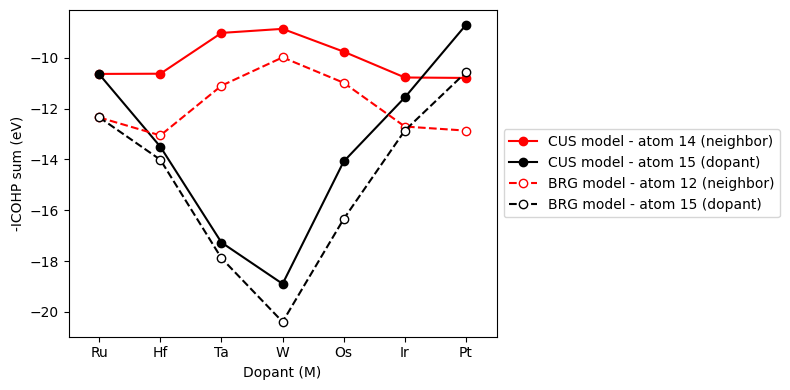

In [ ]:
plt.figure(figsize=(8,4))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

plt.plot(elements, data[f'M14'][0:7], marker='o', label='CUS model - atom 14 (neighbor)', color='red')
plt.plot(elements, data[f'M15'][0:7], marker='o', label='CUS model - atom 15 (dopant)', color='black')

plt.plot(elements, data[f'M12'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - atom 12 (neighbor)', color='red')
plt.plot(elements, data[f'M15'][7:14], marker='o', markerfacecolor='white', linestyle='--',label='BRG model - atom 15 (dopant)', color='black')
    
plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP sum (eV)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/icohp_atom.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

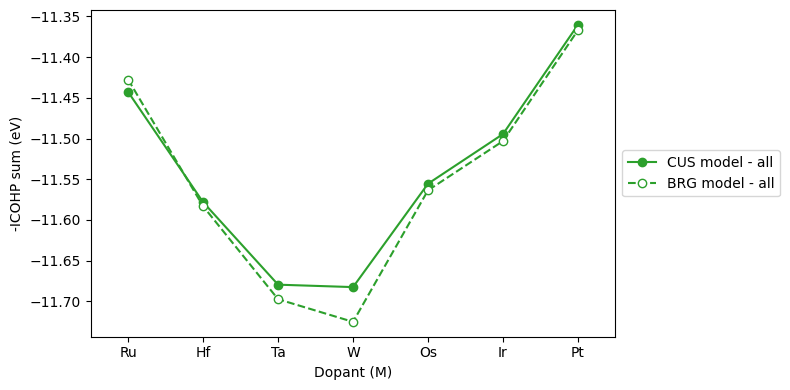

In [ ]:
plt.figure(figsize=(8,4))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

plt.plot(elements, data[f'ICOHP_all'][0:7], marker='o', label='CUS model - all', color='tab:green')
# plt.plot(elements, data[f'ICOHP_top'][0:7], marker='o', label='CUS model - top layer', color='tab:blue')

plt.plot(elements, data[f'ICOHP_all'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - all', color='tab:green')
# plt.plot(elements, data[f'ICOHP_top'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - top layer', color='tab:blue')

    
plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP sum (eV)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/icohp_all.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

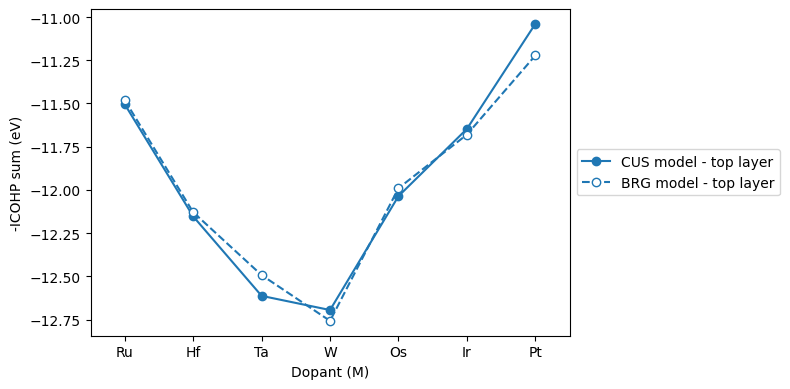

In [ ]:
plt.figure(figsize=(8,4))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

# plt.plot(elements, data[f'ICOHP_all'][0:7], marker='o', label='CUS model - all', color='tab:green')
plt.plot(elements, data[f'ICOHP_top1'][0:7], marker='o', label='CUS model - top layer', color='tab:blue')

# plt.plot(elements, data[f'ICOHP_all'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - all', color='tab:green')
plt.plot(elements, data[f'ICOHP_top1'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - top layer', color='tab:blue')

    
plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP sum (eV)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/icohp_top1.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

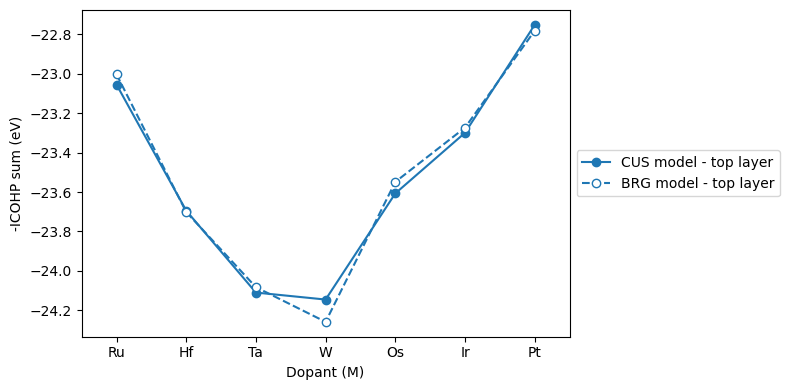

In [ ]:
plt.figure(figsize=(8,4))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

# plt.plot(elements, data[f'ICOHP_all'][0:7], marker='o', label='CUS model - all', color='tab:green')
plt.plot(elements, data[f'ICOHP_top2'][0:7], marker='o', label='CUS model - top layer', color='tab:blue')

# plt.plot(elements, data[f'ICOHP_all'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - all', color='tab:green')
plt.plot(elements, data[f'ICOHP_top2'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - top layer', color='tab:blue')

    
plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP sum (eV)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/icohp_top2.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()